# 02. 定義と基本性質 — 微積分を s の代数へ翻訳する

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 定義の積分・収束域・線形性・微分則・各種シフトという「翻訳辞書」を、記号と数値の両面で作る。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture

ラプラス変換は積分ひとつで定義されます。

$$ F(s) = \mathcal{L}\{f\}(s) = \int_0^\infty f(t)\,e^{-st}\,dt. $$

これは「$f$ を、減衰する波 $e^{-st}$ で測る」操作です。そして線形性・微分則などの **性質** が、
時間の微積分を $s$ の代数へ翻訳する辞書になります。本章でその辞書を作ります。

## 2. Problem

毎回 $e^{st}$ の重ね合わせを手で求めるのは大変です。**系統的に** 時間関数を $s$ 領域へ移し、
しかも微分・畳み込み・初期条件をきれいに扱う仕組みが欲しい。定義の積分とその性質がそれを与えます。

## 3. Intuition — e^{-st} は「測定プローブ」

$e^{-st}$ を掛けて積分するのは、「$f$ の中に、減衰率 $\sigma$・振動 $\omega$ の成分がどれだけあるか」を
測ることです。$\sigma$ を変えると、ゆっくり減る成分・速く減る成分を選り分けられます。

## 4. Visualization — 被積分関数 f(t)e^{-σt} の面積が F(σ)

$f(t)=e^{-t}$ について、$f(t)e^{-\sigma t}$ を数本の $\sigma$ で描きます。曲線の下の面積がちょうど $F(\sigma)$。
$\sigma$ が大きいほど速く減衰し、面積(=$F$)が小さくなります。

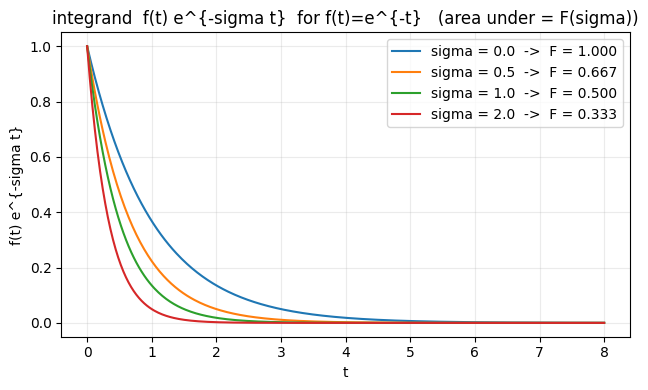

In [2]:
tt = np.linspace(0, 8, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
for sig in [0.0, 0.5, 1.0, 2.0]:
    ax.plot(tt, np.exp(-tt) * np.exp(-sig * tt), label=f"sigma = {sig:.1f}  ->  F = {1/(1+sig):.3f}")
ax.set_title("integrand  f(t) e^{-sigma t}  for f(t)=e^{-t}   (area under = F(sigma))")
ax.set_xlabel("t"); ax.set_ylabel("f(t) e^{-sigma t}"); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()

## 5. Definition と 収束域 (ROC)

$$ F(s)=\int_0^\infty f(t)e^{-st}\,dt, \qquad \text{収束するのは } \operatorname{Re}(s)>\sigma_0. $$

この $\sigma_0$(収束横座標)より右側が **収束域 (ROC)**。$f$ が $e^{\sigma_0 t}$ 程度の増大(指数オーダー)なら
$\sigma > \sigma_0$ で積分が収まります。

## 5b. 両側変換とフーリエの関係 (Advanced)

$s=\sigma+i\omega$ の **虚軸**($\sigma=0$)に制限すると、ラプラス変換はフーリエ変換になる。
因果信号 $f(t)$($t\ge0$、減衰)なら虚軸が収束域に入り、$|F(i\omega)|$ がそのまま **振幅スペクトル**。
下では $f=e^{-2t}$ で $F(i\omega)=1/(2+i\omega)$ を数値確認する。両側変換($t<0$ も含む積分)は
フーリエを一般化した枠組みで、収束域の **帯** で表現が決まる。

max |numeric F(iw) - 1/(2+iw)| = 2.237726045655905e-16


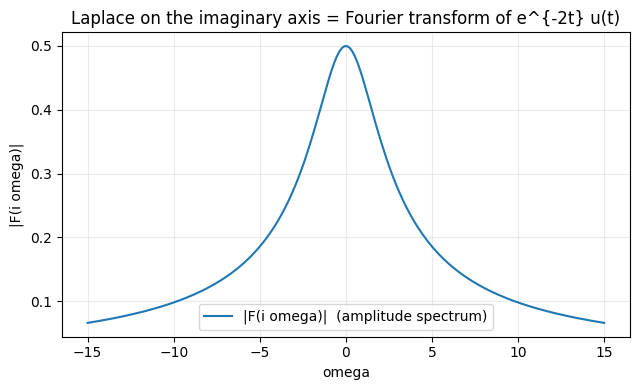

In [3]:
omega = np.linspace(-15, 15, 200)
F_iw = numeric_laplace(lambda x: np.exp(-2 * x), 1j * omega)   # Laplace on the imaginary axis
F_exact = 1.0 / (2.0 + 1j * omega)                            # = Fourier transform of e^{-2t} u(t)
print("max |numeric F(iw) - 1/(2+iw)| =", np.max(np.abs(F_iw - F_exact)))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(omega, np.abs(F_exact), color=plotting.ACCENT, label="|F(i omega)|  (amplitude spectrum)")
ax.set_xlabel("omega"); ax.set_ylabel("|F(i omega)|")
ax.set_title("Laplace on the imaginary axis = Fourier transform of e^{-2t} u(t)")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout()

## 6. Computation — 記号と数値、両方で

SymPy で記号的に、求積で数値的に求め、突き合わせます。

In [4]:
# Symbolic transform of f(t)=e^{-2t}: F(s)=1/(s+2).
F = L(sp.exp(-2 * t))
display(F)

# Numeric transform at s=3 should match 1/(3+2)=0.2.
print("numeric F(3)  =", numeric_laplace(lambda x: np.exp(-2 * x), 3.0))
print("symbolic F(3) =", float(F.subs(s, 3)))

numeric F(3)  = (0.20000000000000004+0j)
symbolic F(3) = 0.2


## 7. Invariant / Structure — 翻訳辞書(基本性質)

| 時間領域 | $s$ 領域 |
|---|---|
| $a f + b g$ | $aF + bG$ (線形性) |
| $f'(t)$ | $sF(s) - f(0)$ |
| $f''(t)$ | $s^2F(s) - s f(0) - f'(0)$ |
| $\int_0^t f$ | $F(s)/s$ |
| $f(t-a)u(t-a)$ | $e^{-as}F(s)$ (時間シフト) |
| $e^{-at}f(t)$ | $F(s+a)$ (周波数シフト) |
| 初期値定理 | $f(0^+)=\lim_{s\to\infty} sF(s)$ |

主役は **微分則** $\mathcal{L}\{f'\}=sF-f(0)$。微分が $s$ の掛け算になり、しかも **初期値 $f(0)$ が自動で入る**。

In [5]:
# Verify the derivative rule symbolically for f(t)=sin(2t).
f_expr = sp.sin(2 * t)
F = L(f_expr)
lhs = L(sp.diff(f_expr, t))            # L{f'}
rhs = s * F - f_expr.subs(t, 0)        # s F(s) - f(0)
print("L{f'} - (sF - f(0)) simplifies to:")
display(sp.simplify(lhs - rhs))
print("derivative rule holds:", transforms.verify_derivative_rule(f_expr))

L{f'} - (sF - f(0)) simplifies to:


derivative rule holds: True


In [6]:
# The same rule, checked numerically: f=e^{-t}, f'=-e^{-t}, at s=2.
f = lambda x: np.exp(-x)
fp = lambda x: -np.exp(-x)
s0 = 2.0
F = numeric_laplace(f, s0)
print("L{f'} numeric :", numeric_laplace(fp, s0))
print("s F - f(0)    :", s0 * F - f(0))   # both should be -1/3

L{f'} numeric : (-0.3333333333333335+0j)
s F - f(0)    : (-0.33333333333333304+0j)


## 8. Failure Mode — ROC を外すと積分が発散 (Applied)

$f(t)=e^{-2t}$ の収束域は $\operatorname{Re}(s)>-2$。$s=3$ では部分積分 $\int_0^{T}$ が $0.2$ に収束しますが、
$s=-3$ では被積分が $e^{t}$ となり、$T$ とともに発散します。

In [7]:
from scipy.integrate import quad

def partial_integral(s_val, t_max):
    return quad(lambda x: np.exp(-2 * x) * np.exp(-s_val * x), 0, t_max)[0]

print(f"{'t_max':>6} {'s=3 (in ROC)':>16} {'s=-3 (outside)':>18}")
for tm in [5, 10, 20, 40]:
    print(f"{tm:>6} {partial_integral(3.0, tm):>16.6f} {partial_integral(-3.0, tm):>18.3e}")

 t_max     s=3 (in ROC)     s=-3 (outside)
     5         0.200000          1.474e+02
    10         0.200000          2.203e+04
    20         0.200000          4.852e+08
    40         0.200000          2.354e+17


$s=3$ 列は $0.2$ に落ち着き、$s=-3$ 列はどんどん大きくなります。**ROC の外では変換が定義されない**、
というのを数値で確かめました。

## 9. Application

- **回路**: コイル・コンデンサの初期電流・初期電圧が、微分則の $f(0)$ として式へ入る(07 章)。
- **制御**: 入力のシフト $e^{-as}$ はむだ時間(遅れ)。
- **ODE**: 初期値問題がそのまま代数に(04 章)。

## 10. Exercises

- **Basic**: 線形性を使って $\mathcal{L}\{3 - 2e^{-t}\}$ を求めよ。
- **Applied**: 周波数シフトで $\mathcal{L}\{e^{-t}\cos 3t\}$ を導き、`transforms.L` で確認せよ。
- **Advanced**: 初期値定理 $f(0^+)=\lim_{s\to\infty}sF(s)$ を $f=\cos\omega t$ で確かめよ。

## 11. Advanced Notes

- **存在条件**: $f$ が区分連続かつ指数オーダー($|f(t)|\le Me^{\sigma_0 t}$)なら $\operatorname{Re}(s)>\sigma_0$ で存在。
- **初期値・最終値定理**: 最終値 $\lim_{t\to\infty}f(t)=\lim_{s\to0}sF(s)$ は、$sF(s)$ の極がすべて左半面のときのみ有効。
- **両側変換との違い**: 本書は片側($t\ge0$)。初期条件の扱いと因果性が片側変換の利点。